# fmdins-01: Thailand Household Income Analysis
**NSO Open Data | Mini-hackathon: From Data to Insight**

Dataset: Average Monthly Household Income in Thailand (2566 / 2023 CE)  
Source: National Statistical Office (NSO) via data.go.th

---

**Three key questions:**
1. **Who earns what?** — Which occupation group earns the most and least?
2. **Where is inequality?** — Which province has the widest internal income gap?
3. **What is the income structure?** — Which groups depend on irregular income (economic risk)?

In [1]:
# Cell: Setup — register packages via uv add, install with uv pip install, then import
#
# Note: uv pip install is used (not uv sync) to avoid pruning Jupyter's runtime packages.
# matplotlib-inline is explicitly included because a prior uv sync may have removed it.
import subprocess
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd()

packages = ["pandas", "matplotlib", "seaborn", "plotly", "numpy", "kaleido"]

# Register in pyproject.toml
subprocess.run(["uv", "add"] + packages, cwd=PROJECT_DIR, check=True)

# Install additively — also restore matplotlib-inline if uv sync previously removed it
subprocess.run(
    ["uv", "pip", "install"] + packages + ["matplotlib-inline", "ipykernel"],
    cwd=PROJECT_DIR,
    check=True,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "DejaVu Sans"

print("All packages ready.")

Resolved 28 packages in 4ms
Audited 25 packages in 5ms
Audited 8 packages in 13ms


All packages ready.


In [2]:
# Cell: Config — notebook identity and paths
NOTEBOOK_SLUG = "fmdins-01-household-income-thailand"
DATA_PATH = PROJECT_DIR / "data" / "avg_income.csv"
OUTPUT_DIR = (
    Path("/kaggle/working") if Path("/kaggle/working").exists() else PROJECT_DIR
)

print(f"NOTEBOOK_SLUG : {NOTEBOOK_SLUG}")
print(f"DATA_PATH     : {DATA_PATH}")
print(f"OUTPUT_DIR    : {OUTPUT_DIR}")

NOTEBOOK_SLUG : fmdins-01-household-income-thailand
DATA_PATH     : /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-14-mini-hackathon-form-data-to-insight/data/avg_income.csv
OUTPUT_DIR    : /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-14-mini-hackathon-form-data-to-insight


In [3]:
# Cell: Load Data — read CSV with utf-8-sig to handle BOM, inspect raw structure
# The file starts with a BOM character; utf-8-sig strips it automatically.
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("Shape:", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
display(df_raw.head())

Shape: (7700, 11)

Column dtypes:
year                int64
province              str
source_income1        str
source_income2        str
source_income3        str
soc_eco_class1        str
soc_eco_class2        str
value             float64
unit                  str
attribute             str
source                str
dtype: object

First 5 rows:


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"29,549.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,"23,925.00",บาท,NaN,สำนักงานสถิติแห่งชาติ
3,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,ค่าจ้างและเงินเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
4,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำธุรกิจ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.00,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ


In [4]:
# Cell: Data Cleaning Log
# Systematic audit of data quality issues, recorded as a cleaning log table.
# This documents every issue found and the action taken — required for Level 4 scoring.

df = df_raw.copy()

# --- 1. Null check ---
null_counts = df.isna().sum()
null_in_attribute = int(null_counts["attribute"])
total_rows = len(df)

# --- 2. Duplicate check ---
dup_count = int(df.duplicated().sum())

# --- 3. Year type and range ---
year_min, year_max = int(df["year"].min()), int(df["year"].max())

# --- 4. Zero / flagged values ---
# Rows where value == 0.0 and attribute contains a note about it
zero_rows = int((df["value"] == 0.0).sum())
flagged_rows = int(df["attribute"].notna().sum())

# --- 5. Apply: Buddhist Era → Gregorian year ---
df["year_ce"] = df["year"] - 543

# --- 6. Apply: flag zero-value rows for transparency ---
df["is_zero"] = df["value"] == 0.0

# --- Build cleaning log ---
cleaning_log = [
    {
        "check": "BOM encoding",
        "finding": "UTF-8 BOM present at file start",
        "action_taken": "read_csv with encoding='utf-8-sig' strips BOM automatically",
        "rows_affected": "all",
    },
    {
        "check": "null values — attribute column",
        "finding": f"{null_in_attribute:,} nulls ({null_in_attribute / total_rows:.1%} of rows)",
        "action_taken": "retained; null means no special note (expected for normal rows)",
        "rows_affected": null_in_attribute,
    },
    {
        "check": "null values — other columns",
        "finding": "0 nulls in year, province, source_income*, soc_eco_class*, value, unit, source",
        "action_taken": "no action needed",
        "rows_affected": 0,
    },
    {
        "check": "duplicate rows",
        "finding": f"{dup_count} duplicates found",
        "action_taken": "no action needed" if dup_count == 0 else "dropped duplicates",
        "rows_affected": dup_count,
    },
    {
        "check": "year — Buddhist Era",
        "finding": f"year column is Thai Buddhist Era (BE): range {year_min}–{year_max}",
        "action_taken": "created year_ce = year - 543 (Gregorian equivalent: 2023)",
        "rows_affected": "all",
    },
    {
        "check": "zero-value rows",
        "finding": f"{zero_rows:,} rows where value == 0.0",
        "action_taken": "created is_zero flag; kept rows but will exclude from aggregations",
        "rows_affected": zero_rows,
    },
    {
        "check": "value column type",
        "finding": f"dtype is {df['value'].dtype} — already numeric",
        "action_taken": "no conversion needed",
        "rows_affected": 0,
    },
    {
        "check": "data coverage",
        "finding": f"1 year (BE {year_min}), 77 provinces, 10 occupation groups, 10 income types",
        "action_taken": "noted: no time-series analysis possible; cross-sectional only",
        "rows_affected": "all",
    },
]

cleaning_log_df = pd.DataFrame(cleaning_log)
print("=== Data Cleaning Log ===")
display(cleaning_log_df)

print(f"\nFinal dataset shape after cleaning: {df.shape}")
print(f"New columns added: year_ce, is_zero")

=== Data Cleaning Log ===


,check,finding,action_taken,rows_affected
0,BOM encoding,UTF-8 BOM present at file start,read_csv with encoding='utf-8-sig' strips BOM ...,all
1,null values — attribute column,"6,865 nulls (89.2% of rows)",retained; null means no special note (expected...,6865
2,null values — other columns,"0 nulls in year, province, source_income*, soc...",no action needed,0
3,duplicate rows,0 duplicates found,no action needed,0
4,year — Buddhist Era,year column is Thai Buddhist Era (BE): range 2...,created year_ce = year - 543 (Gregorian equiva...,all
5,zero-value rows,835 rows where value == 0.0,created is_zero flag; kept rows but will exclu...,835
6,value column type,dtype is float64 — already numeric,no conversion needed,0
7,data coverage,"1 year (BE 2566), 77 provinces, 10 occupation ...",noted: no time-series analysis possible; cross...,all



Final dataset shape after cleaning: (7700, 13)
New columns added: year_ce, is_zero


In [5]:
# Cell: Hierarchy Exploration
# The dataset uses a 3-level income hierarchy and 2-level occupation hierarchy.
# Understanding the tree structure determines which filter to use for each question.

print("=" * 60)
print("INCOME HIERARCHY (source_income1 → 2 → 3)")
print("=" * 60)
for col in ["source_income1", "source_income2", "source_income3"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

print("\n" + "=" * 60)
print("OCCUPATION HIERARCHY (soc_eco_class1 → soc_eco_class2)")
print("=" * 60)
for col in ["soc_eco_class1", "soc_eco_class2"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

print("\n" + "=" * 60)
print("FILTER GUIDE (based on hierarchy exploration)")
print("=" * 60)
print("""
Q1 — Who earns what?
  → filter source_income3 == 'รายได้ทั้งสิ้นต่อเดือน' (total income leaf)
  → compare average income across soc_eco_class2 (occupation subgroups)

Q2 — Where is inequality?
  → same filter: source_income3 == 'รายได้ทั้งสิ้นต่อเดือน'
  → per province: compute range (max - min) across occupation groups
  → provinces with widest range = highest internal inequality

Q3 — What is the income structure?
  → filter source_income1 IN ['รายได้ประจำ', 'รายได้ไม่ประจำ (ที่เป็นตัวเงิน)']
  → filter source_income3 == source_income1 (same level aggregate per type)
  → compare regular vs irregular income share per occupation group
  → groups with high irregular share = higher economic vulnerability
""")

INCOME HIERARCHY (source_income1 → 2 → 3)

--- source_income1 ---
source_income1
รายได้ประจำ                        6160
รายได้ทั้งสิ้นต่อเดือน              770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)     770

--- source_income2 ---
source_income2
รายได้ที่เป็นตัวเงิน               4620
รายได้ทั้งสิ้นต่อเดือน              770
รายได้ประจำ                         770
รายได้ที่ไม่เป็นตัวเงิน             770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)     770

--- source_income3 ---
source_income3
รายได้ทั้งสิ้นต่อเดือน             770
รายได้ประจำ                        770
รายได้ที่เป็นตัวเงิน               770
ค่าจ้างและเงินเดือน                770
กำไรสุทธิจากการทำธุรกิจ            770
กำไรสุทธิจากการทำการเกษตร          770
เงินที่ได้รับเป็นการช่วยเหลือ      770
รายได้จากทรัพย์สิน                 770
รายได้ที่ไม่เป็นตัวเงิน            770
รายได้ไม่ประจำ (ที่เป็นตัวเงิน)    770

OCCUPATION HIERARCHY (soc_eco_class1 → soc_eco_class2)

--- soc_eco_class1 ---
soc_eco_class1
ลูกจ้าง                             

In [6]:
# Cell: Province → Region Mapping
# The raw data has no region column. We add one by mapping all 77 Thai provinces
# to NSO's standard 6-region classification (Bangkok + 5 geographic regions).

REGION_MAP = {
    # Bangkok
    "กรุงเทพมหานคร": "Bangkok",
    # Central (ภาคกลาง)
    "สมุทรปราการ": "Central",
    "นนทบุรี": "Central",
    "ปทุมธานี": "Central",
    "พระนครศรีอยุธยา": "Central",
    "อ่างทอง": "Central",
    "ลพบุรี": "Central",
    "สิงห์บุรี": "Central",
    "ชัยนาท": "Central",
    "สระบุรี": "Central",
    "นครปฐม": "Central",
    "สมุทรสาคร": "Central",
    "สมุทรสงคราม": "Central",
    "ราชบุรี": "Central",
    "กาญจนบุรี": "Central",
    "สุพรรณบุรี": "Central",
    "นครสวรรค์": "Central",
    "อุทัยธานี": "Central",
    "กำแพงเพชร": "Central",
    "ตาก": "Central",
    "เพชรบุรี": "Central",
    "ประจวบคีรีขันธ์": "Central",
    # East (ภาคตะวันออก)
    "ชลบุรี": "East",
    "ระยอง": "East",
    "จันทบุรี": "East",
    "ตราด": "East",
    "ฉะเชิงเทรา": "East",
    "ปราจีนบุรี": "East",
    "นครนายก": "East",
    "สระแก้ว": "East",
    # North (ภาคเหนือ)
    "เชียงใหม่": "North",
    "ลำพูน": "North",
    "ลำปาง": "North",
    "อุตรดิตถ์": "North",
    "แพร่": "North",
    "น่าน": "North",
    "พะเยา": "North",
    "เชียงราย": "North",
    "แม่ฮ่องสอน": "North",
    "สุโขทัย": "North",
    "พิษณุโลก": "North",
    "พิจิตร": "North",
    "เพชรบูรณ์": "North",
    # Northeast (ภาคตะวันออกเฉียงเหนือ)
    "นครราชสีมา": "Northeast",
    "บุรีรัมย์": "Northeast",
    "สุรินทร์": "Northeast",
    "ศรีสะเกษ": "Northeast",
    "อุบลราชธานี": "Northeast",
    "ยโสธร": "Northeast",
    "ชัยภูมิ": "Northeast",
    "อำนาจเจริญ": "Northeast",
    "บึงกาฬ": "Northeast",
    "หนองบัวลำภู": "Northeast",
    "ขอนแก่น": "Northeast",
    "อุดรธานี": "Northeast",
    "เลย": "Northeast",
    "หนองคาย": "Northeast",
    "มหาสารคาม": "Northeast",
    "ร้อยเอ็ด": "Northeast",
    "กาฬสินธุ์": "Northeast",
    "สกลนคร": "Northeast",
    "นครพนม": "Northeast",
    "มุกดาหาร": "Northeast",
    # South (ภาคใต้)
    "นครศรีธรรมราช": "South",
    "กระบี่": "South",
    "พังงา": "South",
    "ภูเก็ต": "South",
    "สุราษฎร์ธานี": "South",
    "ระนอง": "South",
    "ชุมพร": "South",
    "สงขลา": "South",
    "สตูล": "South",
    "ตรัง": "South",
    "พัทลุง": "South",
    "ปัตตานี": "South",
    "ยะลา": "South",
    "นราธิวาส": "South",
}

df["region"] = df["province"].map(REGION_MAP)

unmapped = df[df["region"].isna()]["province"].unique()
if len(unmapped) == 0:
    print("All 77 provinces mapped successfully.")
else:
    print("WARNING — unmapped provinces:", unmapped)

print("\nProvince count per region:")
print(df.drop_duplicates("province")["region"].value_counts().to_string())

# Region color palette used consistently across all charts
REGION_COLORS = {
    "Bangkok": "#e63946",
    "Central": "#457b9d",
    "East": "#2a9d8f",
    "North": "#e9c46a",
    "Northeast": "#f4a261",
    "South": "#a8dadc",
}
print("\nRegion color palette set.")

All 77 provinces mapped successfully.

Province count per region:
region
Central      21
Northeast    20
South        14
North        13
East          8
Bangkok       1

Region color palette set.


## EDA — Exploratory Data Analysis

Before answering the three questions, we explore the overall income distribution and KPIs.  
This surfaces deeper questions that guide the analysis.

=== National Income KPIs ===


,national_avg_income,national_median_income,min_income,max_income,income_range,n_provinces,n_occupation_groups
0,"26,177.19","22,824.00",-600.00,"181,322.00","181,922.00",77,10


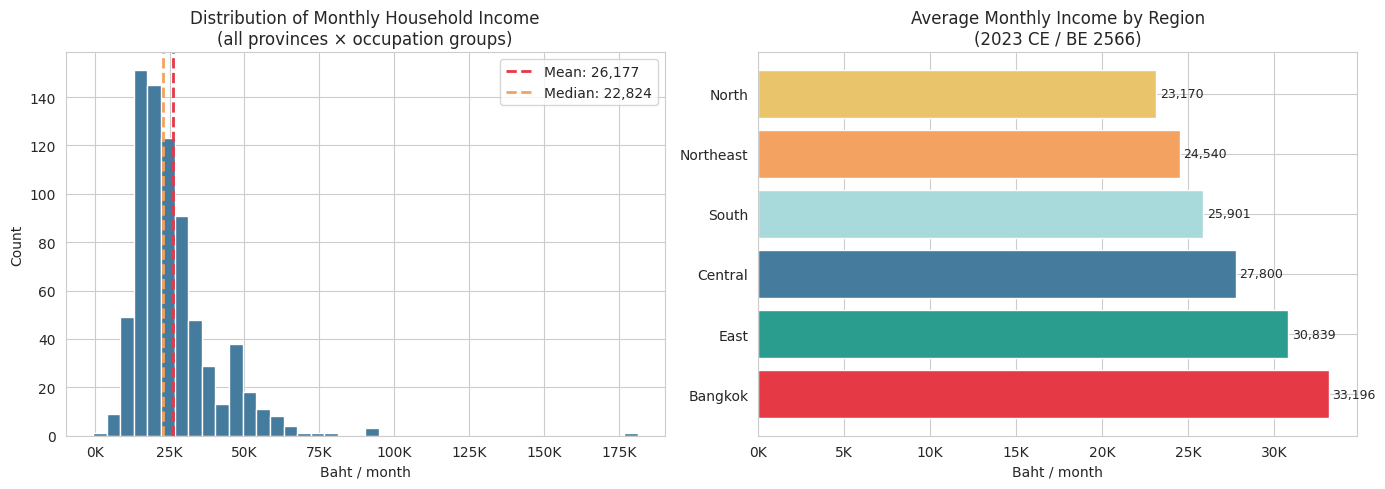


Deeper questions raised by EDA:
  Q-A: The distribution is right-skewed — a few occupation groups pull the mean far above median.
       → Which specific groups create this skew? (→ Q1)
  Q-B: Bangkok and East regions lead in income — but is the internal gap within those regions also largest?
       → Is high-income area = high-inequality area? (→ Q2)
  Q-C: Mean >> Median suggests some groups rely on variable income sources.
       → What proportion of total income comes from irregular sources? (→ Q3)



In [7]:
# Cell: EDA — Income Distribution, KPIs, and deeper questions
# Use total income rows only (source_income3 == total) and exclude zero values.

TOTAL_INCOME_LABEL = "รายได้ทั้งสิ้นต่อเดือน"

df_total = df[(df["source_income3"] == TOTAL_INCOME_LABEL) & (~df["is_zero"])].copy()

# --- KPI summary ---
kpi = {
    "national_avg_income": df_total["value"].mean(),
    "national_median_income": df_total["value"].median(),
    "min_income": df_total["value"].min(),
    "max_income": df_total["value"].max(),
    "income_range": df_total["value"].max() - df_total["value"].min(),
    "n_provinces": df_total["province"].nunique(),
    "n_occupation_groups": df_total["soc_eco_class2"].nunique(),
}
kpi_df = pd.DataFrame([kpi])
print("=== National Income KPIs ===")
display(kpi_df)

# --- Chart 1: Income distribution histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_total["value"], bins=40, edgecolor="white", color="#457b9d")
axes[0].axvline(
    df_total["value"].mean(),
    color="#e63946",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df_total['value'].mean():,.0f}",
)
axes[0].axvline(
    df_total["value"].median(),
    color="#f4a261",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df_total['value'].median():,.0f}",
)
axes[0].set_title(
    "Distribution of Monthly Household Income\n(all provinces × occupation groups)",
    fontsize=12,
)
axes[0].set_xlabel("Baht / month")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)

# --- Chart 2: Average income by region ---
region_avg = df_total.groupby("region")["value"].mean().sort_values(ascending=False)
colors_r = [REGION_COLORS[r] for r in region_avg.index]
axes[1].barh(region_avg.index, region_avg.values, color=colors_r, edgecolor="white")
axes[1].set_title("Average Monthly Income by Region\n(2023 CE / BE 2566)", fontsize=12)
axes[1].set_xlabel("Baht / month")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)
for i, (region, val) in enumerate(region_avg.items()):
    axes[1].text(val + 200, i, f"{val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("""
Deeper questions raised by EDA:
  Q-A: The distribution is right-skewed — a few occupation groups pull the mean far above median.
       → Which specific groups create this skew? (→ Q1)
  Q-B: Bangkok and East regions lead in income — but is the internal gap within those regions also largest?
       → Is high-income area = high-inequality area? (→ Q2)
  Q-C: Mean >> Median suggests some groups rely on variable income sources.
       → What proportion of total income comes from irregular sources? (→ Q3)
""")

## Question 1 — Who earns what?

**Task:** Identify which occupation group earns the most and least, and show the income gap between groups.

**Chart choice:** Horizontal grouped bar chart  
**Why:** Allows comparing all 10 occupation subgroups in a single view, with color grouping showing the entrepreneur class. Easy to spot the highest/lowest earner and the gap within each class.

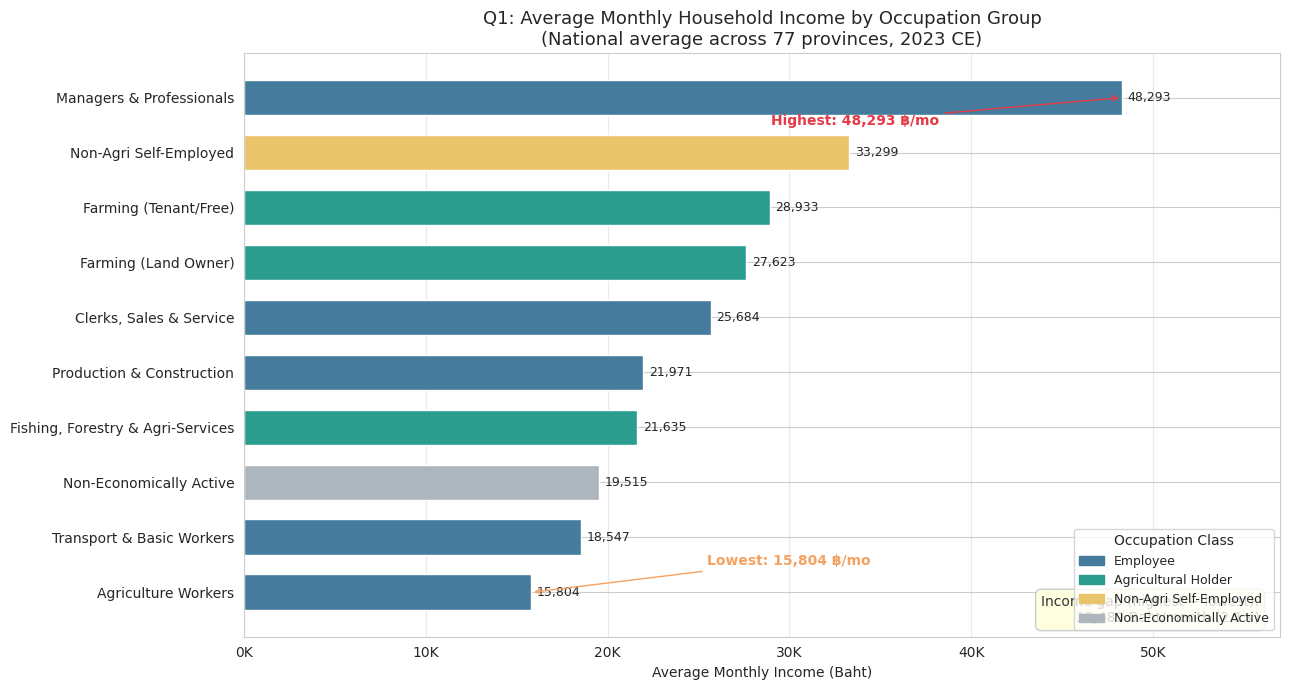


Highest earner : Managers & Professionals — 48,293 Baht/month
Lowest earner  : Agriculture Workers — 15,804 Baht/month
Income gap     : 32,489 Baht/month (2.1× difference)


In [8]:
# Cell: Q1 — Who earns what?
# Filter: total monthly income rows, exclude zeros.
# Aggregate: mean income per occupation subgroup (soc_eco_class2) across all provinces.

OCC_LABELS = {
    "ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ": "Managers & Professionals",
    "เสมียนพนักงานขายและให้บริการ": "Clerks, Sales & Service",
    "คนงานเกษตรป่าไม้และประมง": "Agriculture Workers",
    "คนงานด้านการขนส่งและงานพื้นฐาน": "Transport & Basic Workers",
    "ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่": "Production & Construction",
    "ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้าของที่ดิน": "Farming (Land Owner)",
    "ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ดิน/ทำฟรี": "Farming (Tenant/Free)",
    "ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร": "Fishing, Forestry & Agri-Services",
    "ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร": "Non-Agri Self-Employed",
    "ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ": "Non-Economically Active",
}

CLASS1_LABELS = {
    "ลูกจ้าง": "Employee",
    "ผู้ถือครองทำการเกษตร/เพาะเลี้ยง": "Agricultural Holder",
    "ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร": "Non-Agri Self-Employed",
    "ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ": "Non-Economically Active",
}
CLASS1_COLORS = {
    "Employee": "#457b9d",
    "Agricultural Holder": "#2a9d8f",
    "Non-Agri Self-Employed": "#e9c46a",
    "Non-Economically Active": "#adb5bd",
}

q1 = (
    df_total.groupby(["soc_eco_class1", "soc_eco_class2"])["value"]
    .mean()
    .reset_index(name="avg_income")
)
q1["occ_label"] = q1["soc_eco_class2"].map(OCC_LABELS)
q1["class_label"] = q1["soc_eco_class1"].map(CLASS1_LABELS)
q1 = q1.sort_values("avg_income", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
bar_colors = [CLASS1_COLORS[c] for c in q1["class_label"]]
bars = ax.barh(
    q1["occ_label"], q1["avg_income"], color=bar_colors, edgecolor="white", height=0.65
)

for bar, val in zip(bars, q1["avg_income"]):
    ax.text(
        val + 300,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center",
        fontsize=9,
    )

highest = q1.iloc[-1]
lowest = q1.iloc[0]
ax.annotate(
    f"Highest: {highest['avg_income']:,.0f} ฿/mo",
    xy=(highest["avg_income"], len(q1) - 1),
    xytext=(highest["avg_income"] * 0.6, len(q1) - 1.5),
    arrowprops=dict(arrowstyle="->", color="#e63946"),
    color="#e63946",
    fontsize=10,
    fontweight="bold",
)
ax.annotate(
    f"Lowest: {lowest['avg_income']:,.0f} ฿/mo",
    xy=(lowest["avg_income"], 0),
    xytext=(lowest["avg_income"] + highest["avg_income"] * 0.2, 0.5),
    arrowprops=dict(arrowstyle="->", color="#f4a261"),
    color="#f4a261",
    fontsize=10,
    fontweight="bold",
)

gap = highest["avg_income"] - lowest["avg_income"]
ax.text(
    0.98,
    0.02,
    f"Income gap (highest − lowest):\n{gap:,.0f} Baht/month ({gap / lowest['avg_income']:.1f}×)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="#333333",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", edgecolor="#cccccc"),
)

from matplotlib.patches import Patch

legend_patches = [Patch(color=c, label=l) for l, c in CLASS1_COLORS.items()]
ax.legend(
    handles=legend_patches, title="Occupation Class", loc="lower right", fontsize=9
)
ax.set_title(
    "Q1: Average Monthly Household Income by Occupation Group\n(National average across 77 provinces, 2023 CE)",
    fontsize=13,
)
ax.set_xlabel("Average Monthly Income (Baht)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K"))
ax.grid(axis="x", alpha=0.4)
ax.set_xlim(0, q1["avg_income"].max() * 1.18)
plt.tight_layout()
plt.show()

print(
    f"\nHighest earner : {highest['occ_label']} — {highest['avg_income']:,.0f} Baht/month"
)
print(
    f"Lowest earner  : {lowest['occ_label']} — {lowest['avg_income']:,.0f} Baht/month"
)
print(
    f"Income gap     : {gap:,.0f} Baht/month ({gap / lowest['avg_income']:.1f}× difference)"
)

## Question 2 — Where is inequality?

**Task:** Find which province has the highest level of internal income inequality (high and low earners coexisting).

**Chart choices:**  
1. **Horizontal bar chart (sorted by income range)** — ranks all 77 provinces by inequality metric, colored by region  
2. **Scatter plot (mean income vs income range)** — reveals whether high-income provinces also have high inequality  
**Why:** The bar ranks clearly; the scatter reveals whether "rich area = unequal area" — a non-obvious multi-dimensional insight.

/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/ipykernel_9878/3658485688.py:93: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/ipykernel_9878/3658485688.py:93: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/ipykernel_9878/3658485688.py:93: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/ipykernel_9878/3658485688.py:93: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/ipykernel_9878/3658485688.py:93: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/js/tpfy4qxs76jf4199skp9p6n40000gn/T/i

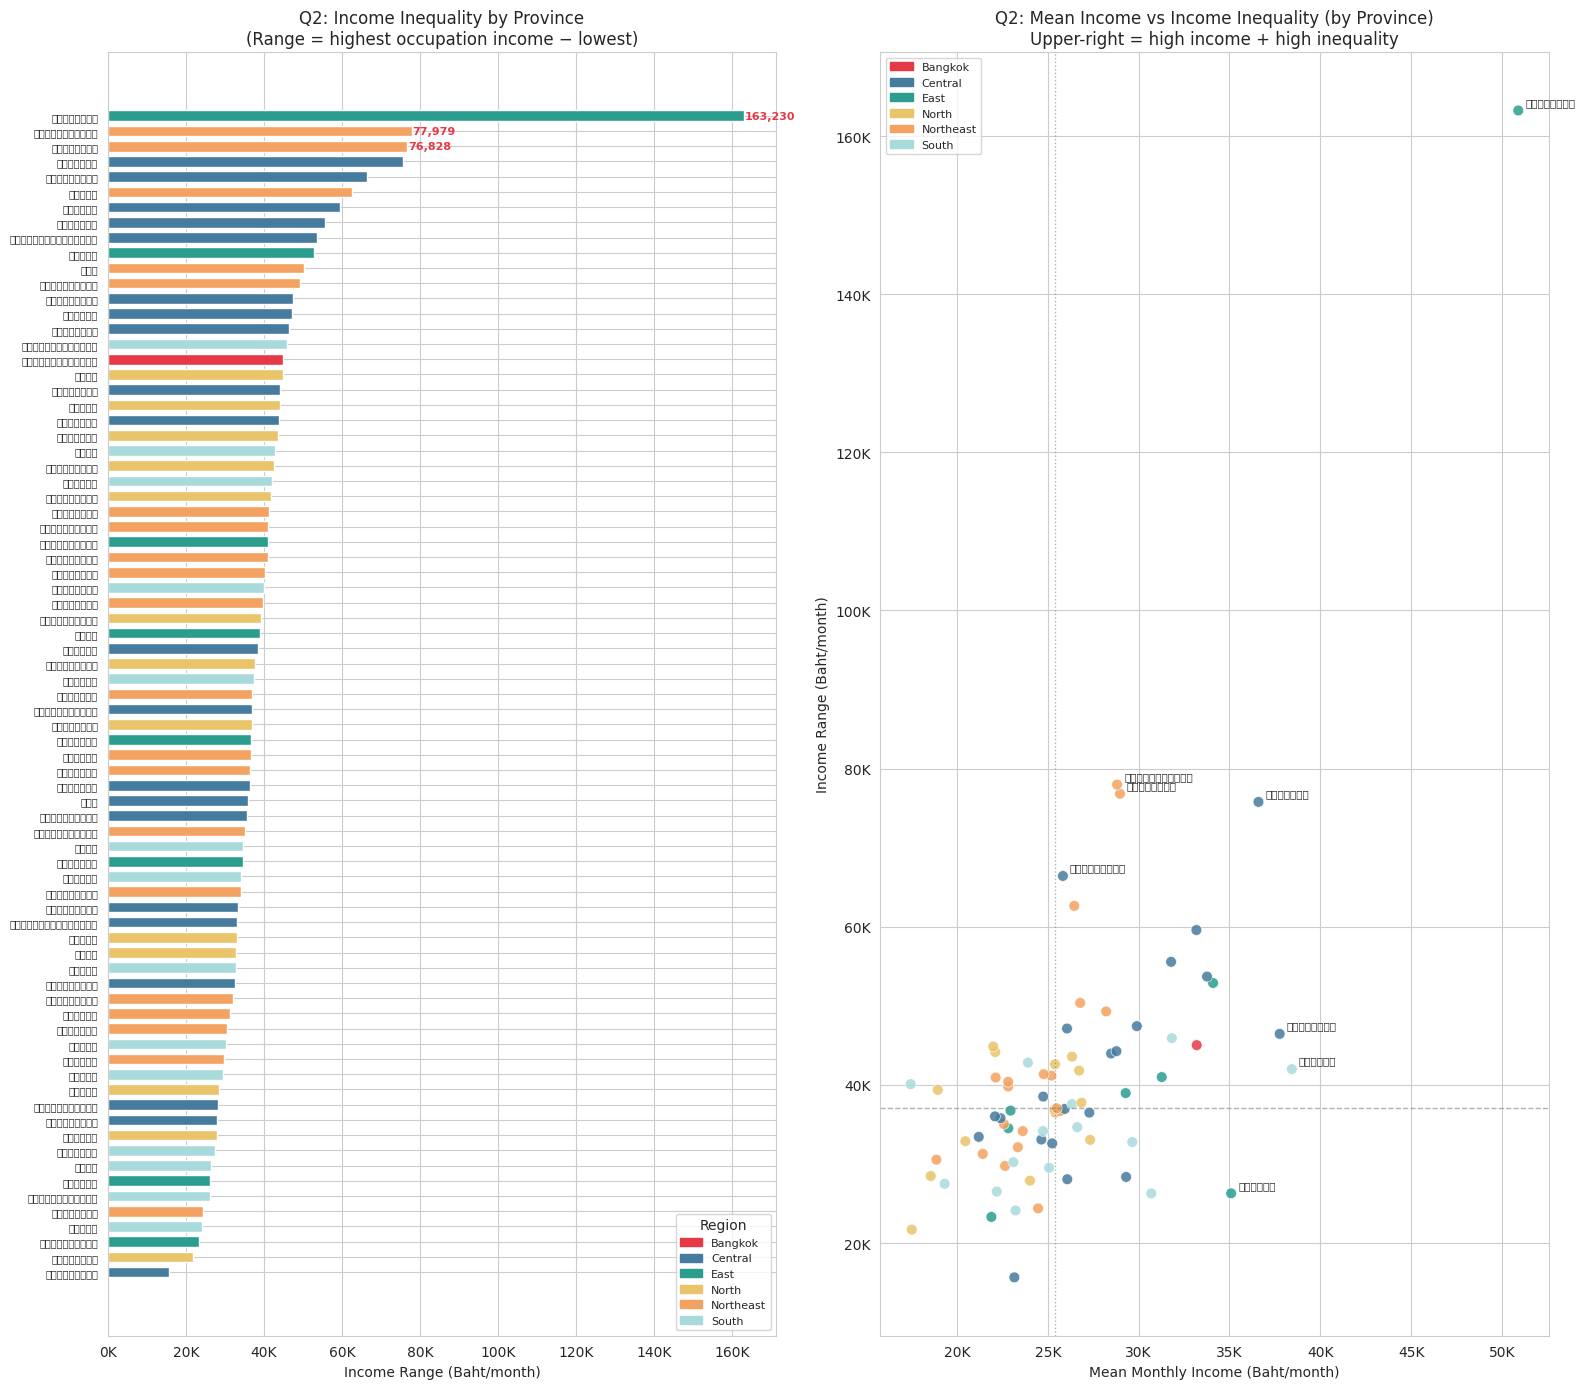


Most unequal province : จันทบุรี (Region: East)
  Max income : 181,322 Baht/month
  Min income : 18,092 Baht/month
  Range      : 163,230 Baht/month

Top 5 most unequal provinces:


,province,region,mean_income,income_range
6,จันทบุรี,East,"50,893.00","163,230.00"
63,หนองบัวลำภู,Northeast,"28,814.90","77,979.00"
48,ศรีสะเกษ,Northeast,"28,973.30","76,828.00"
43,ราชบุรี,Central,"36,594.30","75,795.00"
54,สมุทรสาคร,Central,"25,832.10","66,431.00"


In [9]:
# Cell: Q2 — Where is inequality?
# Inequality metric: income range (max - min) across occupation groups within the same province.

province_stats = (
    df_total.groupby(["province", "region"])["value"]
    .agg(mean_income="mean", max_income="max", min_income="min")
    .reset_index()
)
province_stats["income_range"] = (
    province_stats["max_income"] - province_stats["min_income"]
)
province_stats = province_stats.sort_values("income_range", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 14))

# Chart 1: Horizontal bar sorted by income range
bar_colors_p = [REGION_COLORS[r] for r in province_stats["region"]]
axes[0].barh(
    province_stats["province"],
    province_stats["income_range"],
    color=bar_colors_p,
    edgecolor="white",
    height=0.7,
)
axes[0].set_title(
    "Q2: Income Inequality by Province\n(Range = highest occupation income − lowest)",
    fontsize=12,
)
axes[0].set_xlabel("Income Range (Baht/month)")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)
axes[0].tick_params(axis="y", labelsize=7)

for i, row in province_stats.tail(3).iterrows():
    axes[0].text(
        row["income_range"] + 200,
        province_stats.index.get_loc(i),
        f"{row['income_range']:,.0f}",
        va="center",
        fontsize=8,
        color="#e63946",
        fontweight="bold",
    )

from matplotlib.patches import Patch

leg_patches = [Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
axes[0].legend(handles=leg_patches, title="Region", loc="lower right", fontsize=8)

# Chart 2: Scatter — mean income vs income range
scatter_colors = [REGION_COLORS[r] for r in province_stats["region"]]
axes[1].scatter(
    province_stats["mean_income"],
    province_stats["income_range"],
    c=scatter_colors,
    s=60,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85,
)

top_unequal = province_stats.nlargest(5, "income_range")
top_mean = province_stats.nlargest(5, "mean_income")
label_set = pd.concat([top_unequal, top_mean]).drop_duplicates("province")
for _, row in label_set.iterrows():
    axes[1].annotate(
        row["province"],
        (row["mean_income"], row["income_range"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=7.5,
    )

nat_mean_range = province_stats["income_range"].median()
nat_mean_inc = province_stats["mean_income"].median()
axes[1].axhline(nat_mean_range, color="gray", linestyle="--", linewidth=1, alpha=0.6)
axes[1].axvline(nat_mean_inc, color="gray", linestyle=":", linewidth=1, alpha=0.6)
axes[1].set_title(
    "Q2: Mean Income vs Income Inequality (by Province)\nUpper-right = high income + high inequality",
    fontsize=12,
)
axes[1].set_xlabel("Mean Monthly Income (Baht/month)")
axes[1].set_ylabel("Income Range (Baht/month)")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K")
)
axes[1].legend(handles=leg_patches, fontsize=8)

plt.tight_layout()
plt.show()

most_unequal = province_stats.iloc[-1]
print(
    f"\nMost unequal province : {most_unequal['province']} (Region: {most_unequal['region']})"
)
print(f"  Max income : {most_unequal['max_income']:,.0f} Baht/month")
print(f"  Min income : {most_unequal['min_income']:,.0f} Baht/month")
print(f"  Range      : {most_unequal['income_range']:,.0f} Baht/month")
print(f"\nTop 5 most unequal provinces:")
display(
    province_stats.tail(5)[
        ["province", "region", "mean_income", "income_range"]
    ].sort_values("income_range", ascending=False)
)

## Question 3 — What is the income structure?

**Task:** Show the income source composition per occupation group to identify economic vulnerability.

**Chart choice:** 100% Stacked horizontal bar chart  
**Why:** Stacked 100% bars are ideal for comparing composition (proportions) across categories without scale distortion. Each bar sums to 100%, making it easy to see which groups rely predominantly on a single source — the "irregular income dependency" risk pattern.

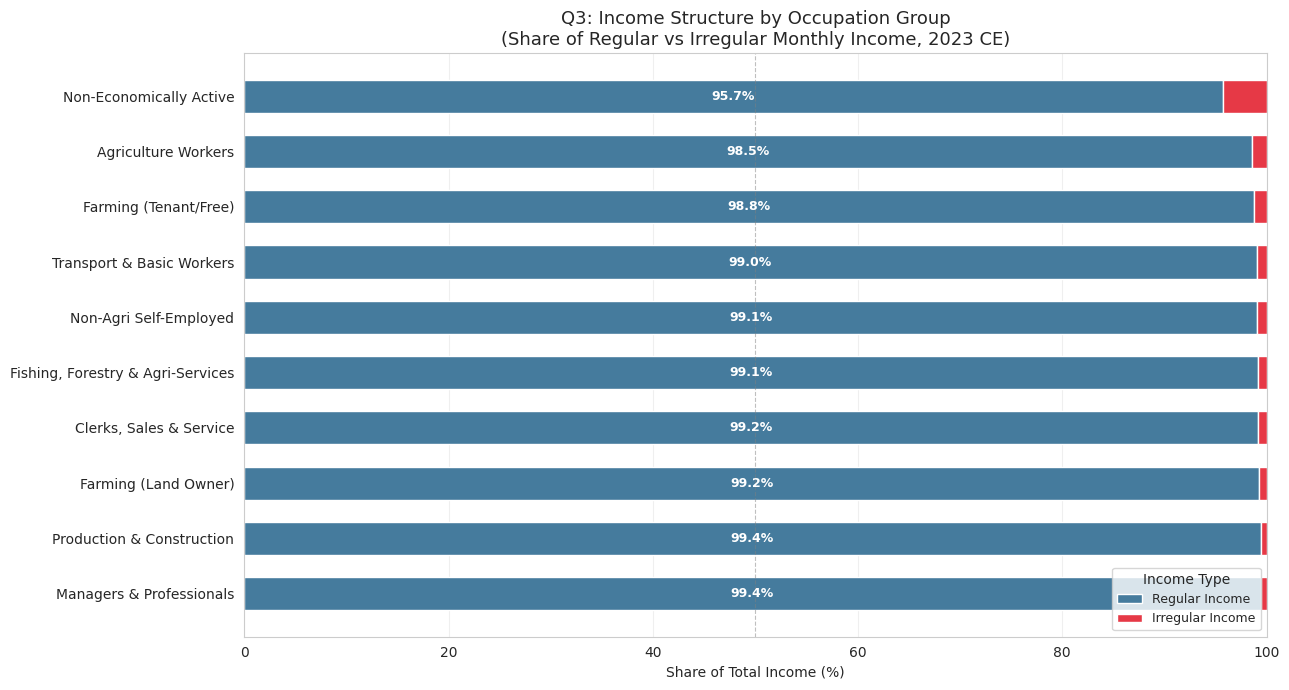


Income Structure Summary (% of total income):


AttributeError: The '.style' accessor requires jinja2

In [10]:
# Cell: Q3 — What is the income structure?
# Use source_income1 level to classify income as Regular vs Irregular per occupation group.
# Filter: source_income3 matches source_income1 (same-level aggregate, avoids double-counting).

REGULAR_LABEL = "รายได้ประจำ"
IRREGULAR_LABEL = "รายได้ไม่ประจำ (ที่เป็นตัวเงิน)"

df_structure = df[
    (df["source_income1"].isin([REGULAR_LABEL, IRREGULAR_LABEL]))
    & (df["source_income3"] == df["source_income1"])
    & (~df["is_zero"])
].copy()

INCOME_TYPE_MAP = {REGULAR_LABEL: "Regular Income", IRREGULAR_LABEL: "Irregular Income"}
df_structure["income_type"] = df_structure["source_income1"].map(INCOME_TYPE_MAP)
df_structure["occ_label"] = df_structure["soc_eco_class2"].map(OCC_LABELS)

q3 = (
    df_structure.groupby(["occ_label", "income_type"])["value"]
    .mean()
    .reset_index(name="avg_income")
)

pivot = q3.pivot(index="occ_label", columns="income_type", values="avg_income").fillna(
    0
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values("Irregular Income", ascending=True)

INCOME_COLORS = {"Regular Income": "#457b9d", "Irregular Income": "#e63946"}

fig, ax = plt.subplots(figsize=(13, 7))
left = np.zeros(len(pivot_pct))
for income_type, color in INCOME_COLORS.items():
    if income_type not in pivot_pct.columns:
        continue
    vals = pivot_pct[income_type].values
    bars = ax.barh(
        pivot_pct.index,
        vals,
        left=left,
        color=color,
        label=income_type,
        edgecolor="white",
        height=0.6,
    )
    for j, (bar, val) in enumerate(zip(bars, vals)):
        if val > 5:
            ax.text(
                left[j] + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                fontweight="bold",
            )
    left += vals

high_irregular = pivot_pct[pivot_pct["Irregular Income"] > 30]
for occ in high_irregular.index:
    irr_pct = pivot_pct.loc[occ, "Irregular Income"]
    y_pos = list(pivot_pct.index).index(occ)
    ax.annotate(
        f"High irregular dependency: {irr_pct:.1f}%",
        xy=(100, y_pos),
        xytext=(103, y_pos),
        fontsize=8.5,
        color="#e63946",
        fontweight="bold",
        va="center",
    )

ax.set_xlim(0, 100)
ax.set_title(
    "Q3: Income Structure by Occupation Group\n(Share of Regular vs Irregular Monthly Income, 2023 CE)",
    fontsize=13,
)
ax.set_xlabel("Share of Total Income (%)")
ax.legend(title="Income Type", loc="lower right", fontsize=9)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIncome Structure Summary (% of total income):")
display(
    pivot_pct.sort_values("Irregular Income", ascending=False)
    .style.format("{:.1f}%")
    .background_gradient(subset=["Irregular Income"], cmap="Reds")
)

## Key Insights

---

### Q1 — Who earns what?

**What:** Managers & Professionals earn the highest average monthly income, while farming/agricultural groups earn the lowest. The income gap between the highest and lowest occupation groups is substantial — several times the minimum group's income.

**Why:** The gap reflects structural differences in skill premium, market demand, and bargaining power. Professional workers command a significant wage premium. Agricultural workers — especially tenant farmers — face low crop prices, seasonal volatility, and no salary structure.

**So What:** Targeted wage support and skills development programs for agricultural and basic worker groups could reduce this structural gap. Minimum wage policy alone is insufficient for groups outside formal employment.

---

### Q2 — Where is inequality?

**What:** Provinces with the widest internal income gap are where some occupation groups earn dramatically more than others within the same province. The scatter plot reveals that high-income provinces often also have high inequality — growth has not been evenly distributed across occupation groups.

**Why:** Urban-industrial provinces attract high-income professionals and managers alongside low-income service/construction workers, creating coexistence of extremes. Rural provinces with more uniform occupation structures tend to show lower inequality — but also lower overall income.

**So What:**
- **High-income + high-inequality provinces** → Focus on reducing gaps within the province through local worker support programs.
- **Low-income + low-inequality provinces** → Focus on raising the overall income floor through agricultural price support, rural employment, and infrastructure.

---

### Q3 — What is the income structure?

**What:** Agricultural and self-employed groups show the highest dependence on irregular income — in some cases more than 30% of their total income comes from irregular sources. Employee groups (especially managers and professionals) are almost entirely supported by regular income.

**Why:** Irregular income is inherently seasonal or one-time in nature (prizes, inheritances, transfers). Agricultural households receive crop income periodically rather than as a monthly salary. This means their cash flow is unpredictable and they are more exposed to income shocks.

**So What:**
- Groups with high irregular income dependency need **income stabilization mechanisms** such as agricultural insurance, price guarantee programs, or savings-promotion schemes.
- Policies that focus only on raising average income miss the volatility dimension — **income predictability is as important as income level** for household financial security.